In [10]:
from sklearn.datasets import fetch_openml
import numpy as np                 # 배열, 샘플추출 및 데이터
from collections import Counter    #라벨 카운터
import matplotlib.pyplot as plt    #시각화 
from sklearn.preprocessing import StandardScaler, MinMaxScaler #스케일링

1. MNIST 데이터셋 불러오기

In [2]:
# MNIST 데이터 불러오기
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data       # 이미지 개당 784크기의 이미지 데이터가 총 70000장 존재
y = mnist.target     # 각 이미지가 0-9중 어떤 숫자인지 알려주는 정답(label)
y = y.astype(int)     # 문자열 → 정수형 전체 변환

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


In [3]:
# y라벨 분포 (숫자 종류별로 몇 장씩 존재하는가)
label_counts = Counter(y)

print("\n라벨 분포 :")
for label, count in sorted(label_counts.items()):   
    print(f"{label}: {count}")


라벨 분포 :
0: 6903
1: 7877
2: 6990
3: 7141
4: 6824
5: 6313
6: 6876
7: 7293
8: 6825
9: 6958


---
2.원본 이미지 간단 시각화

In [4]:
# 랜덤 샘플 이미지 5개 시각화
num_samples = 5 
indices = np.random.choice(len(X), num_samples, replace=False)

In [5]:
plt.figure(figsize=(10, 2)) 

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

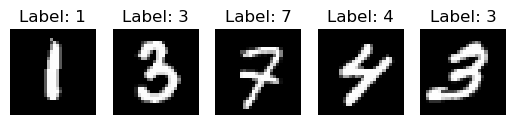

In [6]:
for i, idx in enumerate(indices):   #enumerate : 인덱스와 값 동시반환
    img = X[idx].reshape(28, 28)    # reshape : 28x28 2차원이미지로
    label = y[idx]                  #정답 레이블

    plt.subplot(1, num_samples, i+1) #그림배열
    plt.imshow(img, cmap='gray')    #cmap='gray':흑백 이미지 표시
    plt.title(f"Label: {label}")    #이미지 위 레이블 표시
    plt.axis('off')                 #x, y축 제거

plt.show()

---
3. PCA 적용을 위한 전처리(정규화/표준화)

In [11]:
#PCA 전처리 - StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #스케일링 수행

In [12]:
# 스케일링 전 평균, 분산
original_mean = np.mean(X, axis=0)
original_var = np.var(X, axis=0)

# 스케일링 후 평균, 분산
scaled_mean = np.mean(X_scaled, axis=0)
scaled_var = np.var(X_scaled, axis=0)

print("=== 스케일링 전 평균/분산 ===")
print("평균(일부):", original_mean[:10])
print("분산(일부):", original_var[:10])

print("\n=== 스케일링 후 평균/분산 ===")
print("평균(일부):", scaled_mean[:10])
print("분산(일부):", scaled_var[:10])

=== 스케일링 전 평균/분산 ===
평균(일부): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
분산(일부): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

=== 스케일링 후 평균/분산 ===
평균(일부): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
분산(일부): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
